In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

try:
    import pandas_datareader.data as web
    FRED_AVAILABLE = True
except ImportError:
    FRED_AVAILABLE = False
    print("pandas_datareader not installed — will use fallback for risk-free rate")
    print("Install with: pip install pandas-datareader")

print("Imports OK ✓")

pandas_datareader not installed — will use fallback for risk-free rate
Install with: pip install pandas-datareader
Imports OK ✓


In [2]:
TICKER      = "SPY"
MIN_MONEY   = 0.80    # minimum moneyness K/S to keep (filter deep OTM puts)
MAX_MONEY   = 1.20    # maximum moneyness K/S to keep (filter deep OTM calls)
MIN_VOLUME  = 10      # drop options with fewer contracts traded today
MIN_OI      = 100     # drop options with open interest below this
MAX_SPREAD  = 0.50    # drop options where (ask-bid)/mid > 50% (illiquid)
MIN_PRICE   = 0.05    # drop options priced below 5 cents (noise)
MIN_T       = 7/365   # drop expiries less than 7 calendar days out
MAX_T       = 2.0     # drop expiries beyond 2 years (illiquid LEAPs)

print(f"Target ticker : {TICKER}")
print(f"Moneyness range: [{MIN_MONEY}, {MAX_MONEY}]")

Target ticker : SPY
Moneyness range: [0.8, 1.2]


In [ ]:
ticker_obj = yf.Ticker(TICKER)
info       = ticker_obj.info

S = info.get("regularMarketPrice") or info.get("previousClose")
if S is None:
    hist = ticker_obj.history(period="1d")
    S = float(hist["Close"].iloc[-1])

# Dividend yield
q_raw    = info.get("dividendYield") or info.get("trailingAnnualDividendYield") or 0.0
q_annual = q_raw / 100 if q_raw > 0.20 else q_raw   # normalize to decimal

print(f"\nSpot price (S)  : ${S:.2f}")
print(f"Dividend yield  : {q_annual*100:.2f}%  (raw from yfinance: {q_raw})")
print(f"Currency        : {info.get('currency', 'USD')}")
print(f"Exchange        : {info.get('exchange', 'unknown')}")

# Sanity check
assert S > 0, "Spot price is zero or negative — data fetch failed"
assert 0 <= q_annual <= 0.20, f"Dividend yield {q_annual} still looks wrong after normalization"
print("\nSpot data ✓")


Spot price (S)  : $634.09
Dividend yield  : 1.06%  (raw from yfinance: 1.06)
Currency        : USD
Exchange        : PCX

Spot data ✓


In [ ]:
def get_risk_free_rate():
    """
    Fetch the current 3-month T-bill rate from FRED.
    Falls back to a hardcoded recent value if FRED is unavailable.
    """
    if FRED_AVAILABLE:
        try:
            from datetime import datetime, timedelta
            end   = datetime.today()
            start = end - timedelta(days=30)   
            df = web.DataReader("TB3MS", "fred", start, end)
            rate = float(df["TB3MS"].dropna().iloc[-1]) / 100  
            source = "FRED"
            return rate, source
        except Exception as e:
            print(f"FRED fetch failed: {e}")

    # Fallback: hardcode a recent value — update this manually if needed
    # As of early 2026, 3m T-bill was ~4.3%
    rate   = 0.043
    source = "hardcoded fallback (update manually)"
    return rate, source


r, r_source = get_risk_free_rate()
print(f"Risk-free rate (r): {r*100:.3f}%  [source: {r_source}]")

Risk-free rate (r): 4.300%  [source: hardcoded fallback (update manually)]


In [ ]:
from datetime import datetime, date

expiry_strings = ticker_obj.options   
today          = date.today()

expiries = []
for exp_str in expiry_strings:
    exp_date = datetime.strptime(exp_str, "%Y-%m-%d").date()
    T = (exp_date - today).days / 365.0
    if MIN_T <= T <= MAX_T:
        expiries.append((exp_str, T))

print(f"\nTotal expiries available : {len(expiry_strings)}")
print(f"After T filter [{MIN_T*365:.0f}d, {MAX_T*365:.0f}d]: {len(expiries)}")
print(f"\nExpiries we'll use:")
for exp_str, T in expiries[:12]:   
    print(f"  {exp_str}  (T = {T:.3f} yrs = {T*365:.0f} days)")
if len(expiries) > 12:
    print(f"  ... and {len(expiries)-12} more")

assert len(expiries) >= 3, "Fewer than 3 usable expiries — try a different ticker or time of day"


Total expiries available : 28
After T filter [7d, 730d]: 22

Expiries we'll use:
  2026-04-10  (T = 0.036 yrs = 13 days)
  2026-04-17  (T = 0.055 yrs = 20 days)
  2026-04-24  (T = 0.074 yrs = 27 days)
  2026-04-30  (T = 0.090 yrs = 33 days)
  2026-05-01  (T = 0.093 yrs = 34 days)
  2026-05-15  (T = 0.132 yrs = 48 days)
  2026-05-29  (T = 0.170 yrs = 62 days)
  2026-06-18  (T = 0.225 yrs = 82 days)
  2026-06-30  (T = 0.258 yrs = 94 days)
  2026-07-17  (T = 0.304 yrs = 111 days)
  2026-07-31  (T = 0.342 yrs = 125 days)
  2026-08-21  (T = 0.400 yrs = 146 days)
  ... and 10 more


In [ ]:
def bs_price_fast(S, K, T, r, sigma, q, is_call):
    """Vectorized BS price — minimal version for IV solving."""
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    if is_call:
        return S * np.exp(-q*T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        return K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q*T) * norm.cdf(-d1)


def compute_iv(market_price, S, K, T, r, q, is_call, tol=1e-5):
    """
    Compute implied volatility using Brent's method.
    Returns np.nan if no solution found or inputs fail sanity checks.

    We use Brent over Newton here because it's more robust across
    the full strike range — Newton can fail for deep OTM options
    where vega → 0 and the update step blows up.
    """
    # Basic sanity checks
    if T <= 0 or market_price <= 0 or K <= 0:
        return np.nan

    # Intrinsic value check
    intrinsic = max(S * np.exp(-q*T) - K * np.exp(-r*T), 0) if is_call \
                else max(K * np.exp(-r*T) - S * np.exp(-q*T), 0)
    if market_price < intrinsic * 0.999:
        return np.nan   

    try:
        iv = brentq(
            lambda sig: bs_price_fast(S, K, T, r, sig, q, is_call) - market_price,
            a=1e-4, b=5.0,   
            xtol=tol, maxiter=200
        )
        return iv
    except (ValueError, RuntimeError):
        return np.nan

In [ ]:
def fetch_and_clean_chain(exp_str, T, S, r, q):
    """
    Fetch, clean, and IV-enrich one option chain.

    Returns
    -------
    pd.DataFrame with columns:
        strike, T, mid, bid, ask, volume, openInterest,
        spread_pct, moneyness, iv, option_type
    Returns empty DataFrame if chain is unusable.
    """
    try:
        chain = ticker_obj.option_chain(exp_str)
    except Exception as e:
        print(f"  Failed to fetch {exp_str}: {e}")
        return pd.DataFrame()

    results = []
    for opt_type, df in [("call", chain.calls), ("put", chain.puts)]:
        is_call = (opt_type == "call")
        df = df.copy()

        df["mid"] = (df["bid"] + df["ask"]) / 2

        df["spread_pct"] = np.where(
            df["mid"] > 0,
            (df["ask"] - df["bid"]) / df["mid"],
            np.inf
        )

        df["moneyness"] = df["strike"] / S

        mask = (
            (df["mid"]        >= MIN_PRICE)    &
            (df["volume"]     >= MIN_VOLUME)   &
            (df["openInterest"] >= MIN_OI)     &
            (df["spread_pct"] <= MAX_SPREAD)   &
            (df["moneyness"]  >= MIN_MONEY)    &
            (df["moneyness"]  <= MAX_MONEY)
        )
        df = df[mask].copy()

        if df.empty:
            continue

        # ── Compute IV via BS inversion ──
        df["iv"] = df.apply(
            lambda row: compute_iv(
                market_price = row["mid"],
                S=S, K=row["strike"], T=T, r=r, q=q, is_call=is_call
            ), axis=1
        )

        df = df[df["iv"].notna()]
        df = df[(df["iv"] >= 0.02) & (df["iv"] <= 2.0)]  # 2% to 200% vol

        keep = ["strike", "bid", "ask", "mid", "volume", "openInterest",
                "spread_pct", "moneyness", "iv"]
        df = df[keep].copy()
        df["T"]           = T
        df["expiry"]      = exp_str
        df["option_type"] = opt_type

        results.append(df)

    if results:
        return pd.concat(results, ignore_index=True)
    return pd.DataFrame()


# Fetch all expiries
print("Fetching option chains...")
print(f"S={S:.2f}, r={r*100:.2f}%, q={q_annual*100:.2f}%\n")

all_chains = []
for exp_str, T in expiries:
    df = fetch_and_clean_chain(exp_str, T, S, r, q_annual)
    n  = len(df)
    print(f"  {exp_str} (T={T:.3f}): {n:4d} clean contracts")
    if n > 0:
        all_chains.append(df)

if not all_chains:
    raise RuntimeError("No usable option data fetched. Check ticker and market hours.")

options_df = pd.concat(all_chains, ignore_index=True)
print(f"\nTotal clean contracts: {len(options_df)}")
print(f"Expiries with data  : {options_df['expiry'].nunique()}")
print(f"Call / Put split    : {options_df['option_type'].value_counts().to_dict()}")

Fetching option chains...
S=634.09, r=4.30%, q=1.06%

  2026-04-10 (T=0.036):  170 clean contracts
  2026-04-17 (T=0.055):  182 clean contracts
  2026-04-24 (T=0.074):  151 clean contracts
  2026-04-30 (T=0.090):  208 clean contracts
  2026-05-01 (T=0.093):  132 clean contracts
  2026-05-15 (T=0.132):  162 clean contracts
  2026-05-29 (T=0.170):  161 clean contracts
  2026-06-18 (T=0.225):   83 clean contracts
  2026-06-30 (T=0.258):   86 clean contracts
  2026-07-17 (T=0.304):   51 clean contracts
  2026-07-31 (T=0.342):   73 clean contracts
  2026-08-21 (T=0.400):   58 clean contracts
  2026-08-31 (T=0.427):   36 clean contracts
  2026-09-18 (T=0.477):   74 clean contracts
  2026-09-30 (T=0.510):   68 clean contracts
  2026-12-18 (T=0.726):   75 clean contracts
  2026-12-31 (T=0.762):   51 clean contracts
  2027-01-15 (T=0.803):   75 clean contracts
  2027-03-19 (T=0.975):   64 clean contracts
  2027-06-17 (T=1.222):   43 clean contracts
  2027-12-17 (T=1.723):   39 clean contracts
 

In [8]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

print(f"\nContracts after cleaning   : {len(options_df):,}")
print(f"IV range                   : [{options_df['iv'].min()*100:.1f}%, {options_df['iv'].max()*100:.1f}%]")
print(f"IV mean (calls)            : {options_df[options_df.option_type=='call']['iv'].mean()*100:.1f}%")
print(f"IV mean (puts)             : {options_df[options_df.option_type=='put']['iv'].mean()*100:.1f}%")
print(f"Median bid-ask spread      : {options_df['spread_pct'].median()*100:.1f}%")
print(f"Median volume              : {options_df['volume'].median():.0f} contracts")

# Check for put-call parity violations per expiry
# For same strike and expiry: C - P ≈ S·e^{-qT} - K·e^{-rT}
print("\n--- Put-Call Parity Check (by expiry) ---")
parity_violations = 0
for exp_str in options_df["expiry"].unique():
    sub = options_df[options_df["expiry"] == exp_str]
    T_val = sub["T"].iloc[0]

    calls = sub[sub["option_type"] == "call"].set_index("strike")["mid"]
    puts  = sub[sub["option_type"] == "put"].set_index("strike")["mid"]

    common = calls.index.intersection(puts.index)
    if len(common) < 2:
        continue

    lhs = calls[common] - puts[common]
    rhs = S * np.exp(-q_annual * T_val) - common * np.exp(-r * T_val)
    err = (lhs - rhs).abs()

    # Flag if median parity error > $1 (for SPY trading ~$500, this is 0.2%)
    median_err = err.median()
    flag = "⚠" if median_err > 1.0 else "✓"
    print(f"  {exp_str}: median parity error = ${median_err:.3f}  {flag}")
    if median_err > 1.0:
        parity_violations += 1

if parity_violations == 0:
    print("All expiries pass put-call parity ✓")
else:
    print(f"\n{parity_violations} expiry(ies) with notable parity errors.")
    print("Likely cause: stale quotes at market open/close. Use mid-day data.")

DATA QUALITY REPORT

Contracts after cleaning   : 2,070
IV range                   : [14.6%, 58.8%]
IV mean (calls)            : 20.7%
IV mean (puts)             : 27.2%
Median bid-ask spread      : 1.3%
Median volume              : 134 contracts

--- Put-Call Parity Check (by expiry) ---
  2026-04-10: median parity error = $0.522  ✓
  2026-04-17: median parity error = $0.519  ✓
  2026-04-24: median parity error = $0.375  ✓
  2026-04-30: median parity error = $0.543  ✓
  2026-05-01: median parity error = $0.368  ✓
  2026-05-15: median parity error = $0.603  ✓
  2026-05-29: median parity error = $0.552  ✓
  2026-06-18: median parity error = $0.516  ✓
  2026-06-30: median parity error = $1.635  ⚠
  2026-07-17: median parity error = $1.934  ⚠
  2026-07-31: median parity error = $1.690  ⚠
  2026-08-21: median parity error = $1.577  ⚠
  2026-08-31: median parity error = $1.505  ⚠
  2026-09-18: median parity error = $1.537  ⚠
  2026-09-30: median parity error = $1.992  ⚠
  2026-12-18: median

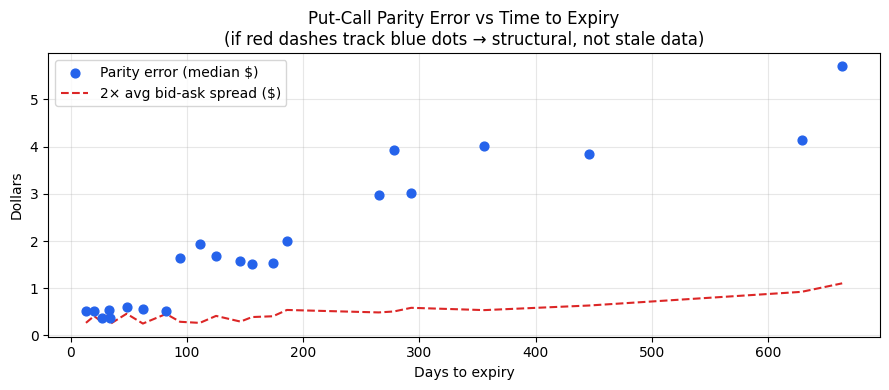

Correlation between T and parity error: 0.943
(>0.85 confirms structural cause, not stale quotes)


In [9]:
# Confirms errors are structural (grow with T), not random (stale data)

parity_rows = []
for exp_str in options_df["expiry"].unique():
    sub   = options_df[options_df["expiry"] == exp_str]
    T_val = sub["T"].iloc[0]
    calls = sub[sub["option_type"]=="call"].set_index("strike")["mid"]
    puts  = sub[sub["option_type"]=="put"].set_index("strike")["mid"]
    common = calls.index.intersection(puts.index)
    if len(common) < 2:
        continue
    lhs = calls[common] - puts[common]
    rhs = S * np.exp(-q_annual*T_val) - common * np.exp(-r*T_val)
    parity_rows.append({"expiry": exp_str, "T": T_val,
                         "parity_error": (lhs - rhs).abs().median(),
                         "avg_spread":   sub["spread_pct"].median() * sub["mid"].median()})

par_df = pd.DataFrame(parity_rows).sort_values("T")

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(par_df["T"]*365, par_df["parity_error"],
           s=40, color="#2563EB", zorder=3, label="Parity error (median $)")
ax.plot(par_df["T"]*365, par_df["avg_spread"]*2,
        color="#DC2626", lw=1.5, ls="--", label="2× avg bid-ask spread ($)")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("Dollars")
ax.set_title("Put-Call Parity Error vs Time to Expiry\n"
             "(if red dashes track blue dots → structural, not stale data)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the correlation
corr = par_df[["T","parity_error"]].corr().iloc[0,1]
print(f"Correlation between T and parity error: {corr:.3f}")
print("(>0.85 confirms structural cause, not stale quotes)")

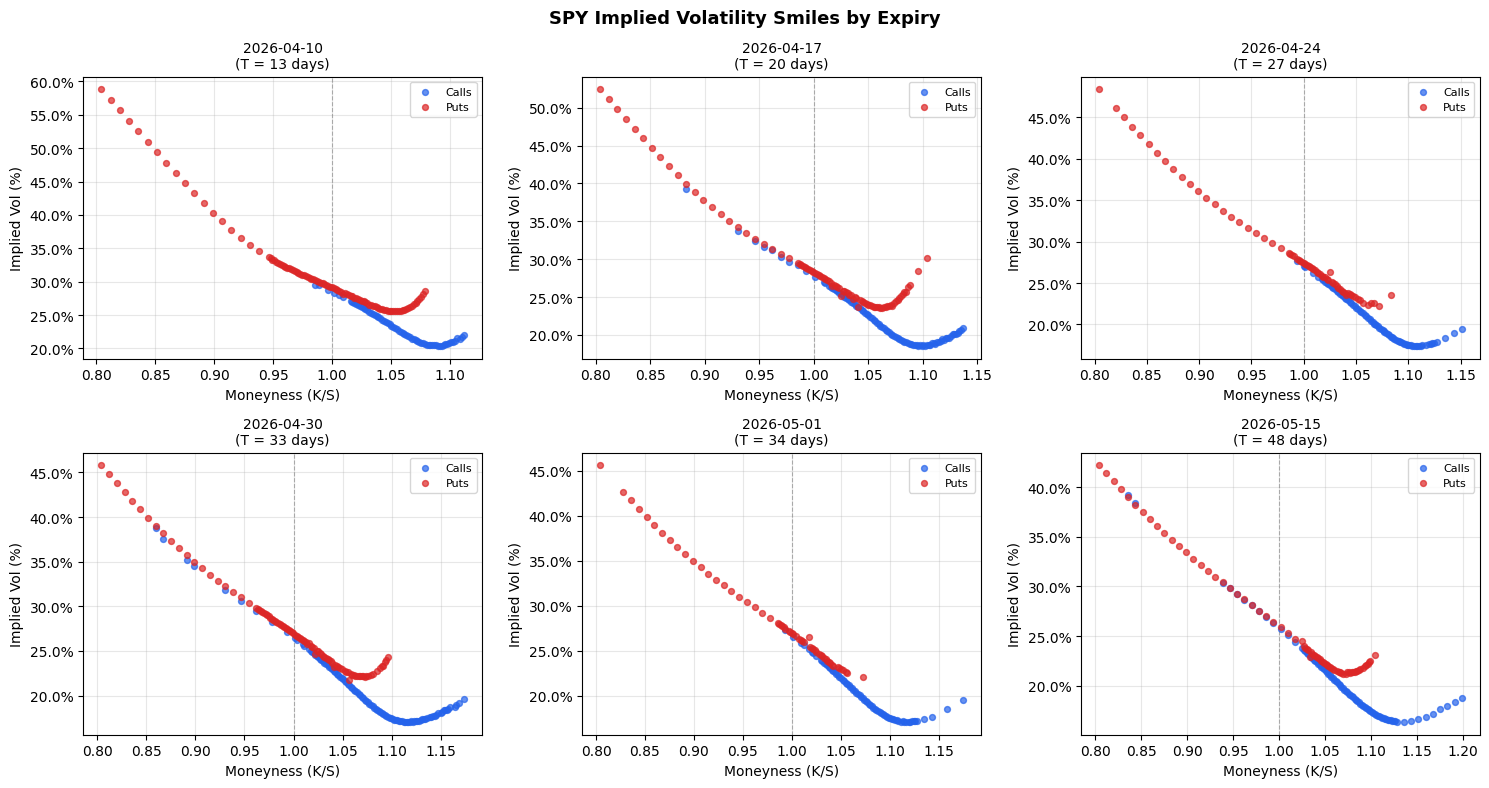

In [ ]:
expiry_list = options_df["expiry"].unique()[:6]  
n_plots = len(expiry_list)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, exp_str in enumerate(expiry_list):
    ax  = axes[i]
    sub = options_df[options_df["expiry"] == exp_str]
    T_val = sub["T"].iloc[0]

    calls = sub[sub["option_type"] == "call"].sort_values("moneyness")
    puts  = sub[sub["option_type"] == "put"].sort_values("moneyness")

    ax.scatter(calls["moneyness"], calls["iv"] * 100,
               s=18, color="#2563EB", alpha=0.7, label="Calls", zorder=3)
    ax.scatter(puts["moneyness"],  puts["iv"]  * 100,
               s=18, color="#DC2626", alpha=0.7, label="Puts",  zorder=3)

    ax.axvline(1.0, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(f"{exp_str}\n(T = {T_val*365:.0f} days)", fontsize=10)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Implied Vol (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Hide unused subplots
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{TICKER} Implied Volatility Smiles by Expiry", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/iv_smiles_by_expiry.png", dpi=150, bbox_inches="tight")
plt.show()

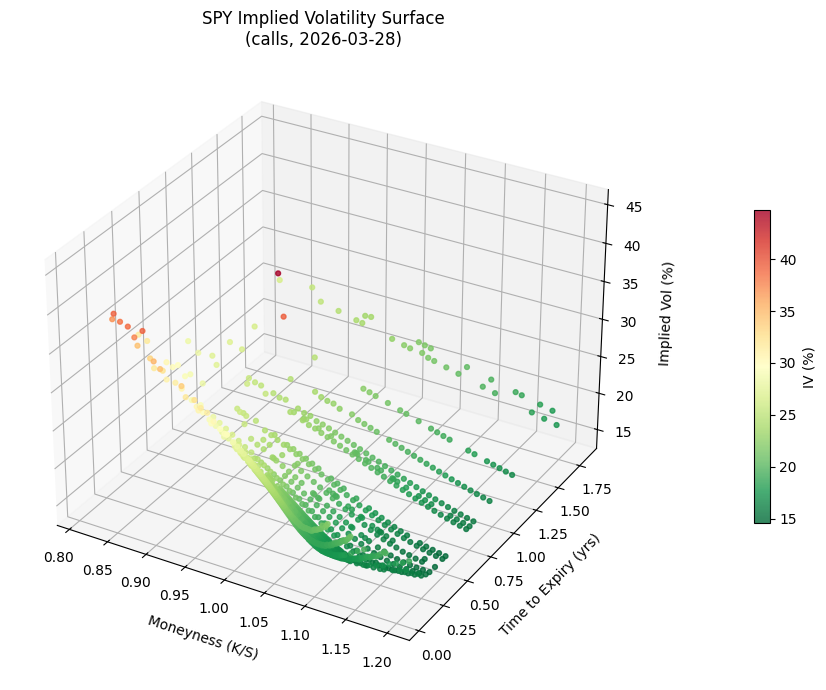

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# Use call IVs only for the surface (puts give same info, calls are cleaner far OTM)
surface_df = options_df[options_df["option_type"] == "call"].copy()
surface_df = surface_df.sort_values(["T", "moneyness"])

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    surface_df["moneyness"],
    surface_df["T"],
    surface_df["iv"] * 100,
    c     = surface_df["iv"] * 100,
    cmap  = "RdYlGn_r",      # red = high vol (OTM puts side), green = low
    s     = 12,
    alpha = 0.8,
)

ax.set_xlabel("Moneyness (K/S)", labelpad=8)
ax.set_ylabel("Time to Expiry (yrs)", labelpad=8)
ax.set_zlabel("Implied Vol (%)", labelpad=8)
ax.set_title(f"{TICKER} Implied Volatility Surface\n(calls, {date.today()})", fontsize=12)

cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label("IV (%)")

plt.tight_layout()
plt.savefig("../outputs/iv_surface_3d.png", dpi=150, bbox_inches="tight")
plt.show()

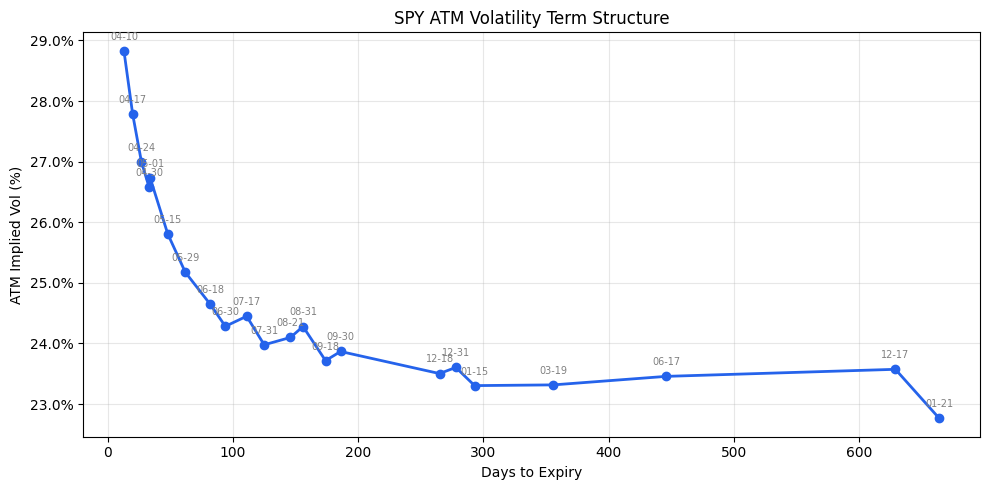


ATM IV by expiry:
    expiry        T       iv  n
2026-04-10 0.035616 0.288297 34
2026-04-17 0.054795 0.277817 31
2026-04-24 0.073973 0.269940 28
2026-04-30 0.090411 0.265845 33
2026-05-01 0.093151 0.267280 22
2026-05-15 0.131507 0.258072 10
2026-05-29 0.169863 0.251753 27
2026-06-18 0.224658 0.246443 10
2026-06-30 0.257534 0.242827 18
2026-07-17 0.304110 0.244491  5
2026-07-31 0.342466 0.239777 13
2026-08-21 0.400000 0.240997  8
2026-08-31 0.427397 0.242794  2
2026-09-18 0.476712 0.237165 10
2026-09-30 0.509589 0.238677 12
2026-12-18 0.726027 0.235033  9
2026-12-31 0.761644 0.236046 10
2027-01-15 0.802740 0.233045 10
2027-03-19 0.975342 0.233166  7
2027-06-17 1.221918 0.234571  6
2027-12-17 1.723288 0.235734  7
2028-01-21 1.819178 0.227646  4


In [12]:
atm_band = options_df[
    (options_df["moneyness"] >= 0.98) &
    (options_df["moneyness"] <= 1.02)
].copy()

atm_by_expiry = atm_band.groupby("expiry").agg(
    T    = ("T", "first"),
    iv   = ("iv", "median"),
    n    = ("iv", "count")
).reset_index().sort_values("T")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(atm_by_expiry["T"] * 365, atm_by_expiry["iv"] * 100,
        "o-", color="#2563EB", lw=2, ms=6)

for _, row in atm_by_expiry.iterrows():
    ax.annotate(row["expiry"][5:],   # show MM-DD only
                xy=(row["T"] * 365, row["iv"] * 100),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=7, color="gray")

ax.set_xlabel("Days to Expiry")
ax.set_ylabel("ATM Implied Vol (%)")
ax.set_title(f"{TICKER} ATM Volatility Term Structure")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/iv_term_structure.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nATM IV by expiry:")
print(atm_by_expiry[["expiry", "T", "iv", "n"]].to_string(index=False))

In [13]:
import os
from datetime import date

os.makedirs("data", exist_ok=True)
save_path = f"../data/{TICKER}_options_{date.today()}.csv"

options_df.to_csv(save_path, index=False)
print(f"Saved {len(options_df)} clean contracts to: {save_path}")

# Also save the market parameters (spot, r, q) in a small metadata file
meta = {
    "ticker":   TICKER,
    "date":     str(date.today()),
    "spot":     S,
    "r":        r,
    "q":        q_annual,
    "n_contracts": len(options_df),
    "n_expiries":  options_df["expiry"].nunique(),
}
pd.Series(meta).to_csv(f"../data/{TICKER}_meta_{date.today()}.csv", header=False)
print("Metadata saved ✓")
print("\nData snapshot:")
print(options_df.groupby("expiry").agg(
    T        = ("T", "first"),
    n_calls  = ("option_type", lambda x: (x == "call").sum()),
    n_puts   = ("option_type", lambda x: (x == "put").sum()),
    iv_min   = ("iv", lambda x: f"{x.min()*100:.1f}%"),
    iv_max   = ("iv", lambda x: f"{x.max()*100:.1f}%"),
    iv_atm   = ("iv", "median"),
).to_string())

Saved 2070 clean contracts to: ../data/SPY_options_2026-03-28.csv
Metadata saved ✓

Data snapshot:
                   T  n_calls  n_puts iv_min iv_max    iv_atm
expiry                                                       
2026-04-10  0.035616       67     103  20.4%  58.8%  0.268296
2026-04-17  0.054795       91      91  18.6%  52.4%  0.246692
2026-04-24  0.073973       81      70  17.4%  48.4%  0.235956
2026-04-30  0.090411      107     101  17.1%  45.8%  0.232456
2026-05-01  0.093151       73      59  17.1%  45.6%  0.231844
2026-05-15  0.131507       88      74  16.4%  42.2%  0.218619
2026-05-29  0.169863       75      86  15.8%  39.8%  0.223303
2026-06-18  0.224658       40      43  15.4%  37.9%  0.244418
2026-06-30  0.257534       30      56  14.9%  36.7%  0.241426
2026-07-17  0.304110       23      28  14.7%  35.7%  0.220384
2026-07-31  0.342466       32      41  14.6%  33.5%  0.219373
2026-08-21  0.400000       26      32  14.6%  34.0%  0.231252
2026-08-31  0.427397       19    

In [14]:
print("\n" + "="*55)
print("DATA READINESS CHECKLIST")
print("="*55)

checks = {
    "Spot price fetched"                    : S > 0,
    "Risk-free rate fetched"                : 0 < r < 0.15,
    "Dividend yield fetched"                : 0 <= q_annual < 0.10,
    "At least 3 usable expiries"            : options_df["expiry"].nunique() >= 3,
    "At least 100 clean contracts"          : len(options_df) >= 100,
    "IV range sane (5%-100%)"               : (options_df["iv"].between(0.05, 1.0)).mean() > 0.9,
    "Both calls and puts present"           : options_df["option_type"].nunique() == 2,
    "ATM IV term structure computed"        : len(atm_by_expiry) >= 3,
    "Data saved to disk"                    : os.path.exists(save_path),
}

all_pass = True
for check, result in checks.items():
    icon = "✓" if result else "✗"
    print(f"  {icon}  {check}")
    if not result:
        all_pass = False

print("\n" + "="*55)
if all_pass:
    print("ALL CHECKS PASSED — data pipeline is solid.")
    print("You are unblocked to build Phases 1–6.")
else:
    print("Some checks failed. See diagnostics above.")
    print("Most common fix: run during US market hours (9:30–16:00 ET)")
    print("or try AAPL/QQQ if SPY data looks stale.")
print("="*55)


DATA READINESS CHECKLIST
  ✓  Spot price fetched
  ✓  Risk-free rate fetched
  ✓  Dividend yield fetched
  ✓  At least 3 usable expiries
  ✓  At least 100 clean contracts
  ✓  IV range sane (5%-100%)
  ✓  Both calls and puts present
  ✓  ATM IV term structure computed
  ✓  Data saved to disk

ALL CHECKS PASSED — data pipeline is solid.
You are unblocked to build Phases 1–6.


In [15]:
def load_options_data(ticker="SPY", data_dir="data", force_refresh=False):
    """
    Primary  : fetch fresh from yfinance
    Fallback : load most recently saved snapshot if yfinance fails

    Parameters
    ----------
    force_refresh : bool — if True, skip fallback attempt and raise on failure
                           useful when you explicitly want live data or nothing
    """
    # ── Try yfinance first ──
    try:
        print("Attempting live fetch from yfinance...")
        # reuse the exact pipeline from Cells 3-7
        ticker_obj = yf.Ticker(ticker)
        info       = ticker_obj.info

        S     = info.get("regularMarketPrice") or info.get("previousClose")
        if S is None:
            S = float(ticker_obj.history(period="1d")["Close"].iloc[-1])

        q_raw    = info.get("dividendYield") or info.get("trailingAnnualDividendYield") or 0.0
        q_annual = q_raw / 100 if q_raw > 0.20 else q_raw

        r, _ = get_risk_free_rate()

        expiry_strings = ticker_obj.options
        today          = date.today()
        expiries = [
            (e, (datetime.strptime(e, "%Y-%m-%d").date() - today).days / 365.0)
            for e in expiry_strings
        ]
        expiries = [(e, T) for e, T in expiries if MIN_T <= T <= MAX_T]

        assert len(expiries) >= 3, "Fewer than 3 usable expiries returned"

        all_chains = []
        for exp_str, T in expiries:
            df = fetch_and_clean_chain(exp_str, T, S, r, q_annual)
            if not df.empty:
                all_chains.append(df)

        assert all_chains, "No usable chains after cleaning"
        options_df = pd.concat(all_chains, ignore_index=True)
        assert len(options_df) >= 100, f"Only {len(options_df)} contracts — too few"

        # Save fresh snapshot
        os.makedirs(data_dir, exist_ok=True)
        today_str  = str(today)
        save_path  = f"{data_dir}/{ticker}_options_{today_str}.csv"
        meta_path  = f"{data_dir}/{ticker}_meta_{today_str}.csv"

        options_df.to_csv(save_path, index=False)
        pd.Series({"ticker": ticker, "date": today_str, "spot": S,
                   "r": r, "q": q_annual,
                   "n_contracts": len(options_df),
                   "n_expiries": options_df["expiry"].nunique()
                   }).to_csv(meta_path, header=False)

        print(f"Live data fetched and saved → {save_path}")
        print(f"Contracts: {len(options_df):,}  |  Expiries: {options_df['expiry'].nunique()}")
        print(f"S={S:.2f}, r={r*100:.3f}%, q={q_annual*100:.2f}%")
        return options_df, S, r, q_annual, today_str, "live"

    except Exception as e:
        if force_refresh:
            raise RuntimeError(f"Live fetch failed and force_refresh=True: {e}")

        print(f"Live fetch failed: {e}")
        print("Falling back to most recent saved snapshot...")

    # ── Fallback: load latest saved file ──
    import glob
    files = sorted(glob.glob(f"{data_dir}/{ticker}_options_*.csv"))

    if not files:
        raise FileNotFoundError(
            "No saved snapshots found either.\n"
            "Run during US market hours (9:30–16:00 ET) to fetch live data."
        )

    latest    = files[-1]
    date_str  = latest.split("_options_")[1].replace(".csv", "")
    meta_path = f"{data_dir}/{ticker}_meta_{date_str}.csv"
    meta      = pd.read_csv(meta_path, header=None, index_col=0).squeeze()

    options_df = pd.read_csv(latest)
    S, r, q_annual = float(meta["spot"]), float(meta["r"]), float(meta["q"])

    print(f"Loaded snapshot: {date_str}  ⚠ not today's data")
    print(f"Contracts: {len(options_df):,}  |  Expiries: {options_df['expiry'].nunique()}")
    print(f"S={S:.2f}, r={r*100:.3f}%, q={q_annual*100:.2f}%")
    return options_df, S, r, q_annual, date_str, "cached"


# ── Usage — one line in every future notebook ──
options_df, S, r, q_annual, snapshot_date, data_source = load_options_data("SPY")

if data_source == "cached":
    print("\n⚠  Using cached data — results reflect market conditions on", snapshot_date)
    print("   Re-run during market hours for current calibration.")
else:
    print(f"\n✓  Using live data from {snapshot_date}")

Attempting live fetch from yfinance...
Live data fetched and saved → data/SPY_options_2026-03-28.csv
Contracts: 2,070  |  Expiries: 22
S=634.09, r=4.300%, q=1.06%

✓  Using live data from 2026-03-28
